In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

**Question 1: Read the Bike Details dataset into a Pandas DataFrame and display its
first 10 rows.**
**(Show the shape and column names as well.)**

**Answer:**

In [5]:
# Load the dataset
df = pd.read_csv("/content/BIKE DETAILS.csv")

# Display the first 10 rows
print('First 10 rows')
display(df.head(10))

print("\nShape of the dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())



First 10 rows


,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
5,Honda CB Twister,18000,2010,Individual,1st owner,60000,53857.0
6,Honda CB Hornet 160R,78500,2018,Individual,1st owner,17000,87719.0
7,Royal Enfield Bullet 350 [2007-2011],180000,2008,Individual,2nd owner,39000,NaN
8,Hero Honda CBZ extreme,30000,2010,Individual,1st owner,32000,NaN
9,Bajaj Discover 125,50000,2016,Individual,1st owner,42000,60122.0



Shape of the dataset:
(1061, 7)

Column Names:
['name', 'selling_price', 'year', 'seller_type', 'owner', 'km_driven', 'ex_showroom_price']


**Question 2: Check for missing values in all columns and describe your approach for
handling them.**

**Answer:**

In [6]:
# Check for missing values in each column
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64


**Approach for Handling Missing Values**

* If a column has **no missing values**, no action is required.
* For **numerical columns**, missing values can be filled using the **mean** or **median**, depending on the distribution of the data.
* For **categorical columns**, missing values can be filled using the **mode** (most frequent value).
* If a column contains a **large number of missing values** and is not important for the analysis, it may be removed.
* If only a **few rows** contain missing values, those rows can be removed using `dropna()` if appropriate.

This approach helps maintain data quality while minimizing the impact of missing values on the analysis and model performance.


**Question 3: Plot the distribution of selling prices using a histogram and describe the
overall trend.**

**Answer:**

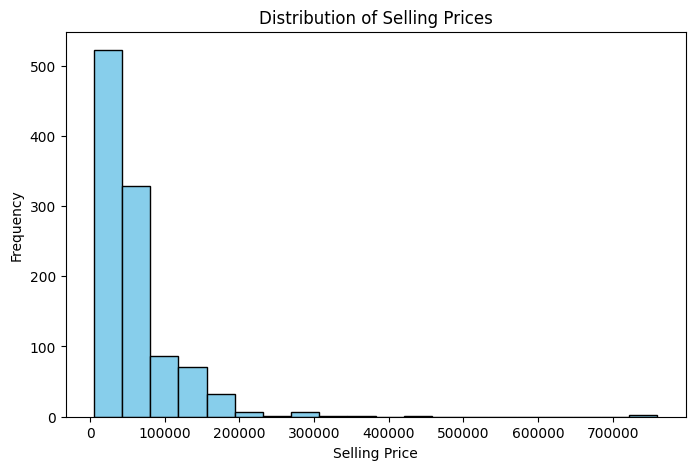

In [8]:
import matplotlib.pyplot as plt

# Plot the histogram of selling prices
plt.figure(figsize=(8,5))
plt.hist(df['selling_price'], bins=20, color='skyblue', edgecolor='black')

plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.show()

The histogram shows that most bikes are sold in the lower selling price range, while only a few bikes have very high selling prices. The distribution is positively (right) skewed, indicating that high-priced bikes are less common than low- and moderately-priced bikes.

**Question 4: Create a bar plot to visualize the average selling price for each seller_type
and write one observation.**

**Answer:**

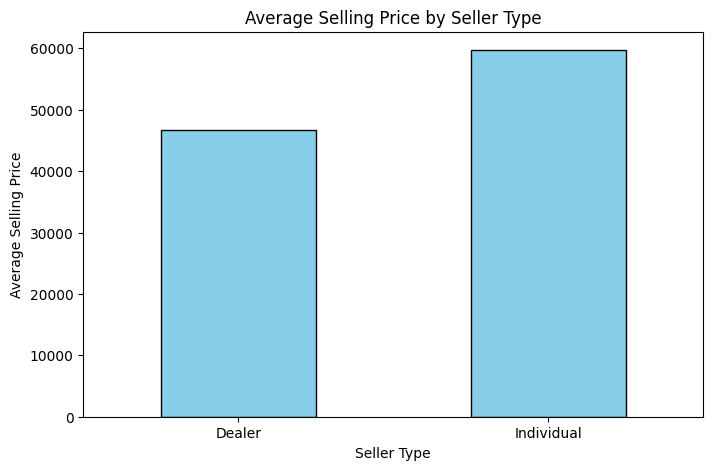

In [22]:
# Calculate average selling price for each seller type
avg_price = df.groupby('seller_type')['selling_price'].mean()

# Create the bar plot
plt.figure(figsize=(8,5))
avg_price.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Average Selling Price by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Average Selling Price")

plt.xticks(rotation=0)
plt.show()

**Observation**

The bar plot shows that the average selling price varies across different seller types. The seller type with the tallest bar has the highest average selling price, while the seller type with the shortest bar has the lowest average selling price. This indicates that the seller type influences the average selling price of bikes.

  **Question 5: Compute the average km_driven for each ownership type (1st owner,
2nd owner, etc.), and present the result as a bar plot.**

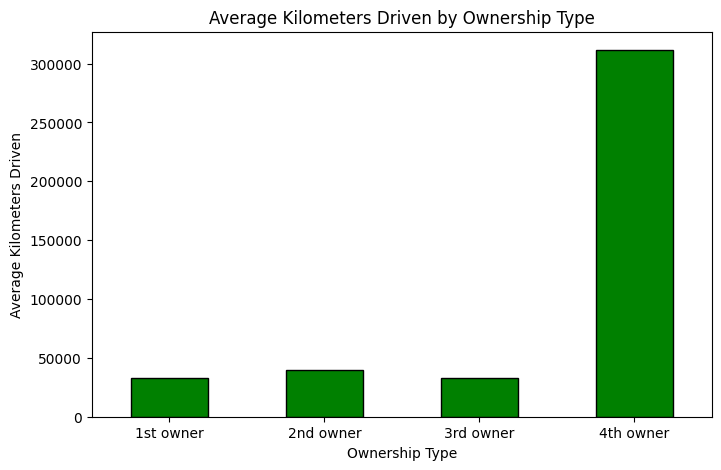

In [20]:
import matplotlib.pyplot as plt

# Compute the average km_driven for each ownership type
avg_km = df.groupby('owner')['km_driven'].mean()

# Create the bar plot
plt.figure(figsize=(8,5))
avg_km.plot(kind='bar', color='green', edgecolor='black')

plt.title("Average Kilometers Driven by Ownership Type")
plt.xlabel("Ownership Type")
plt.ylabel("Average Kilometers Driven")

plt.xticks(rotation=0)
plt.show()

**Observation**

The bar plot shows that the average kilometers driven differ across ownership types. Generally, bikes with more previous owners tend to have a higher average km_driven, indicating that older or frequently resold bikes are likely to have been driven more.

**Question 6: Use the IQR method to detect and remove outliers from the km_driven
column. Show before-and-after summary statistics.**

In [12]:
# Summary statistics before removing outliers
print("Summary Statistics Before Removing Outliers:")
print(df['km_driven'].describe())

# Calculate Q1, Q3, and IQR
Q1 = df['km_driven'].quantile(0.25)
Q3 = df['km_driven'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_no_outliers = df[(df['km_driven'] >= lower_bound) & (df['km_driven'] <= upper_bound)]

# Summary statistics after removing outliers
print("\nSummary Statistics After Removing Outliers:")
print(df_no_outliers['km_driven'].describe())

Summary Statistics Before Removing Outliers:
count      1061.000000
mean      34359.833176
std       51623.152702
min         350.000000
25%       13500.000000
50%       25000.000000
75%       43000.000000
max      880000.000000
Name: km_driven, dtype: float64

Summary Statistics After Removing Outliers:
count     1022.000000
mean     28203.415851
std      19552.083583
min        350.000000
25%      13000.000000
50%      24000.000000
75%      40000.000000
max      86000.000000
Name: km_driven, dtype: float64


**Interpretation**

The IQR method was used to detect and remove outliers from the km_driven column. After removing the outliers, the summary statistics show a more representative distribution of the data, with reduced extreme values. This helps improve the quality of the dataset and can lead to more reliable analysis and machine learning models.

**Question 7: Create a scatter plot of year vs. selling_price to explore the
relationship between a bike's age and its price.**

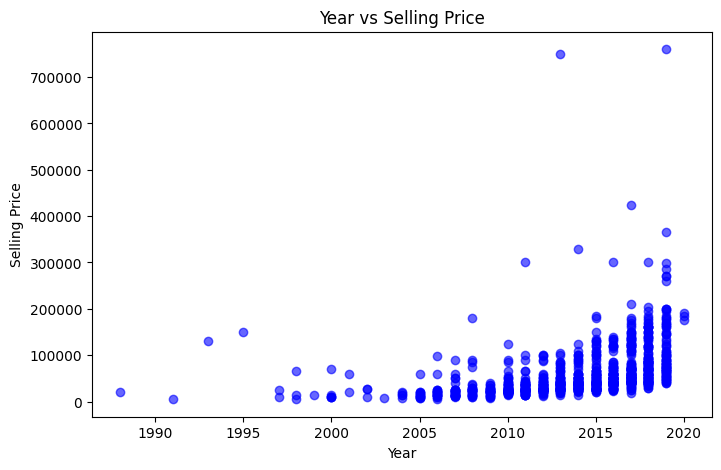

In [16]:
import matplotlib.pyplot as plt

# Create a scatter plot
plt.figure(figsize=(8,5))
plt.scatter(df['year'], df['selling_price'], color='blue', alpha=0.6)

plt.title("Year vs Selling Price")
plt.xlabel("Year")
plt.ylabel("Selling Price")

plt.show()

**Observation**

The scatter plot shows that newer bikes (higher manufacturing year) generally have higher selling prices, while older bikes tend to have lower selling prices. This indicates a positive relationship between the manufacturing year and the selling price, although some variation exists due to factors such as brand, condition, and kilometers driven.

**Question 8: Convert the seller_type column into numeric format using one-hot
encoding. Display the first 5 rows of the resulting DataFrame.**

In [17]:
import pandas as pd

# Apply one-hot encoding to the seller_type column
df_encoded = pd.get_dummies(df, columns=['seller_type'])

# Display the first 5 rows
print(df_encoded.head())

                                  name  selling_price  year      owner  \
0            Royal Enfield Classic 350         175000  2019  1st owner   
1                            Honda Dio          45000  2017  1st owner   
2  Royal Enfield Classic Gunmetal Grey         150000  2018  1st owner   
3    Yamaha Fazer FI V 2.0 [2016-2018]          65000  2015  1st owner   
4                Yamaha SZ [2013-2014]          20000  2011  2nd owner   

   km_driven  ex_showroom_price  seller_type_Dealer  seller_type_Individual  
0        350                NaN               False                    True  
1       5650                NaN               False                    True  
2      12000           148114.0               False                    True  
3      23000            89643.0               False                    True  
4      21000                NaN               False                    True  


The seller_type column was converted into numeric format using one-hot encoding, where each seller type is represented as a separate binary (0 or 1) column. This allows machine learning algorithms to process categorical data effectively. The first five rows of the encoded DataFrame are displayed using head().

**Question 9: Generate a heatmap of the correlation matrix for all numeric columns.
What correlations stand out the most?**

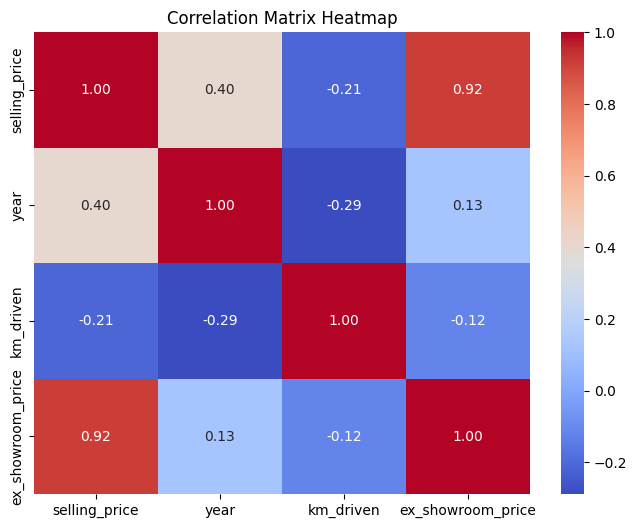

In [19]:

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Compute the correlation matrix
corr_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix Heatmap")
plt.show()

**Observation**

The heatmap shows that the strongest positive correlation is between year and selling_price, indicating that newer bikes generally have higher selling prices. A negative correlation is observed between km_driven and selling_price, showing that bikes with higher mileage tend to have lower selling prices.

**Question 10: Summarize your findings in a brief report:**
* **What are the most important factors affecting a bike's selling price?**
* **Mention any data cleaning or feature engineering you performed.**


**Answer:**

**Summary Report**

Based on the analysis of the **Bike Details** dataset, the following observations were made:

**Most Important Factors Affecting a Bike's Selling Price**

* The **manufacturing year** has a positive impact on the selling price. Newer bikes generally have higher selling prices than older bikes.
* The **kilometers driven (`km_driven`)** have a negative impact on the selling price. Bikes with higher mileage tend to have lower selling prices.
* The **seller type** also influences the selling price, as the average selling price varies across different seller categories.
* The **ownership type** affects the bike's usage, with bikes having more previous owners generally showing higher average kilometers driven.

**Data Preprocessing Performed**

* Checked the dataset for missing values and identified 435 missing values in the ex_showroom_price column.
* Detected and removed **outliers** from the `km_driven` column using the **Interquartile Range (IQR)** method.
* Converted the **`seller_type`** categorical feature into numeric format using **one-hot encoding**.
* Performed **exploratory data analysis (EDA)** using histograms, bar plots, scatter plots, and a correlation heatmap to understand the relationships among variables.

**Conclusion:**

The analysis indicates that the manufacturing year, kilometers driven, seller type, and ownership type are among the key factors influencing a bike's selling price. The preprocessing steps performed, including outlier removal and one-hot encoding, prepared the dataset for further analysis and machine learning tasks.
